# Finding the Likely Path Between Nuclei (with NetworkX)

We can also use NetworkX to find the most probably path between nuclei in the network.

Consider the reaction $X(a,b)Z$.  This will compete with all of the other reactions that consume nucleus $X$, so
we can compute the probability (or branching ratio) of $X(a,b)Z$ being taken as:

$$p_{X(a,b)Z} = \frac{{\dot Y}_{X(a,b)Z}}{\sum {\dot Y}_\mbox{reactions consuming X}}$$

where $\dot{Y}$ is the full expression for the rates contribution to the $dY/dt$ evolution (i.e., includes density and molar fraction terms).

Now, if we want to compute the probability of taking a path from nucleus $A$ to $B$ in a network, we would compute

$$P_\mathrm{path} = \prod_{\lambda \in \mbox{path}} p_\lambda$$

and if we want to find the most likely path, then we want to find the path that has the maximum $P_\mathrm{path}$.

```{note}
In our $p_{X(a,b)Z}$, the molar fraction of the reactant, $Y(X)$, cancels out.  This is what we want, since a path may be probably even if the abundance of the reactant is small because it is not a waiting-point, i.e., there is a lot of flow through that nucleus.
```

In NetworkX, the graph algorithms can minimize the distance through a network, so we need to express our $P_\mathrm{path}$ in a way that is compatible with this.  We observe that:

$$\log P_\mathrm{path} = \log \left ( \prod_{\lambda \in \mbox{path}} p_\lambda \right ) = \sum_{\lambda \in \mbox{path}} \log p_\lambda$$

Since NetworkX will find the minimum distance, if we set the edge weights in our network to be 

$$w_\lambda = -\log p_\lambda$$

then we can find the most probably path by asking NetworkX to find the shortest path.

The method {py:meth}`create_network_graph <pynucastro.networks.rate_collection.RateCollection.create_network_graph>` can assign
this weighting to the exported NetworkX graph by setting ``use_branching_ratios = True``.

In [1]:
import pynucastro as pyna
import networkx as nx

## A CNO example

We'll start with a CNO + breaking network

In [2]:
nuclei = ["p", "he4",
          "c12", "c13",
          "n13", "n14", "n15",
          "o14", "o15", "o16", "o17", "o18",
          "f17", "f18", "f19",
          "ne18", "ne19", "ne20"]

In [3]:
net = pyna.network_helper(nuclei, tabular_ordering=["ffn", "oda"])

Let's pick a thermodynamic state this is hot enough to expect breakout from hot-CNO

In [4]:
rho = 1.e4
T = 5.e8
comp = pyna.Composition(net.unique_nuclei, init="solar")
state = pyna.ThermoState(rho=rho, T=T, comp=comp)

Now we evaluate the rates (using {py:meth}`evaluate_rates <pynucastro.networks.rate_collection.RateCollection.evaluate_rates>`---this gives us a ``dict`` of the $\dot{Y}$ terms:

In [5]:
rates = net.evaluate_rates(state)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 b

Here's a visual representation of the network at this state

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 b

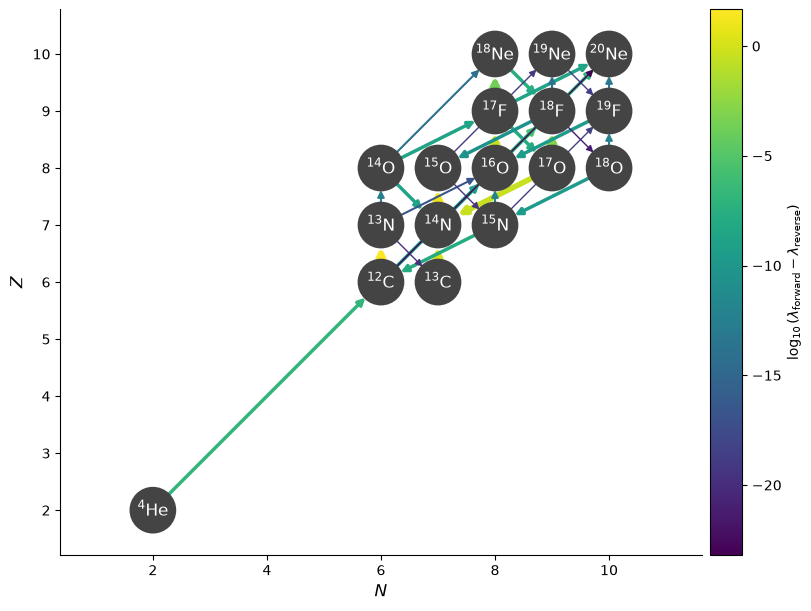

In [6]:
fig = net.plot(rho=rho, T=T, comp=comp, use_net_rate=True)

Now we can create the network graph.

```{important}
Note that by default, we don't include edges connecting ${}^4\mathrm{He}$ to its products directly (this is controlled by ``hide_xalpha=True``).  This is the behavior we want---we only want to consider the edges connecting the heavy nuclei, since $\alpha$ are involved in a lot of reactions.  Put another way, we only want each reaction to map to a single edge in the network, not multiple edges connecting different nuclei.
```

In [7]:
G = net.create_network_graph(net.unique_nuclei, # hide_xalpha=False,
                             rate_ydots=rates, use_branching_ratios=True)

Finally, we can use the NetworkX ``shortest_path`` function.  Let's find the path between ${}^{12}\mathrm{C}$ and ${}^{18}\mathrm{F}$

In [8]:
weighted_path = nx.shortest_path(G,
                                 source=pyna.Nucleus("c12"),
                                 target=pyna.Nucleus("f18"),
                                 weight="weight")

we see the most probably path is:

In [9]:
weighted_path

[C12, N13, O14, F17, Ne18, F18]

Looking at the figure showing the rates, we see that the two rates leaving ${}^{14}\mathrm{O}$ are very close in magnitude.  We can see the branching probabilities from the graph:

In [10]:
import numpy as np

In [11]:
for u, v, data in G.edges(data=True):
    if u == pyna.Nucleus("o14"):
        print(f"{u!s:4}-> {v!s:4}: p = {np.exp(-data["weight"]):8.3g}")

O14 -> N14 : p =    0.413
O14 -> Ne18: p = 2.95e-06
O14 -> F17 : p =    0.587
O14 -> N13 : p = 1.04e-34


We see that the path to ${}^{14}\mathrm{N}$ is almost as likely as the path to ${}^{17}\mathrm{F}$